# This Notebook is a workbook! It is not complete and will not fully run straight through correctly. 

### The notebook is set up for HD 189733b SPIRou data. Your task is to set up this notebook to run STARSHIPS for WASP-127b given the data in this container from NIRPS. Warning: there are also missing parameters and files which will trigger errors

# Introduction to STARSHIPS Reduction

**STARSHIPS**  
*Spectral Transmission and Radiation Search for High Resolution Planet Signal*

STARSHIPS is a pipeline designed to remove the stellar spectrum signature and residuals from high-resolution time-series data to extract the planetary signal. It generates synthetic sequences and prepares the data for cross-correlation, working order-by-order.

The reduction process consists of several main steps:
1. **Bad Pixel Correction and Masking:** Identify and mask bad pixels in the data.
2. **Spectral Alignment:** Shift each spectrum to align the stellar signal by correcting for barycentric Earth radial velocity (BERV).
3. **Telluric Line Masking:** Identify and mask regions affected by deep telluric absorption.
4. **Reference Spectrum Removal:** Build a master reference spectrum from the aligned spectra and subtract it.
5. **PCA Residual Removal:** Apply principal component analysis (PCA) to remove quasi-static vertical residuals. Typically, multiple numbers of principal components (nPC) are tested.

---

## Working with SPIRou or NIRPS Data

- Data format is typically (number of exposures, number of orders, number of pixels), with >4000 pixels per order.
- Initial calibrations are performed by the **APERO** pipeline.

**APERO** performs:
- Dark correction, bad pixel correction, background subtraction
- Detector nonlinearity correction, order localization, geometric correction
- Flat field correction, blaze correction, hot pixel and cosmic ray removal
- Telluric correction
- Wavelength calibration using the Fabry-Perot etalon method

Reference: [APERO Pipeline Paper](https://iopscience.iop.org/article/10.1088/1538-3873/ac9e74)

APERO produces three main data products:
- **E2DS**: Original extracted spectra
- **TCORR**: Spectra corrected for tellurics
- **RCONN**: Synthetic telluric spectrum

The wavelength solution is handled separately. STARSHIPS will either use the available solution or reconstruct it from the file headers using the `planet_obs.py` functions.

---

## Data Organization and Preprocessing

- APERO outputs are organized by target, not by observation date.
- Observations must be split into individual nights/visits using the "split nights".
- This step sorts by Barycentric Julian Date (BJD) and reduction type, identifying observation gaps.

The sorted observations are saved into files named like:

These files are required for input into STARSHIPS.

Each notebook typically runs one visit reduction at a time.

---

## Adapting STARSHIPS for Other Instruments

STARSHIPS is designed to be flexible:
- Supported instruments currently include SPIRou, NIRPS (APERO and Geneva/ESPRESSO reductions), and IGRINS.
- Modifications to instrument headers can be made inside `planet_obs.py`.



In [30]:
#we are NOT running petitRADTRANS in this tutorial however, starships needs it to run. 
#we are tricking the container here to believe we have petitRADTRANS when infact all the functions are empty

import sys
import types

# Top-level dummy package
petitRADTRANS = types.ModuleType("petitRADTRANS")

# Submodules as separate mock modules/namespaces
petitRADTRANS.Radtrans = object  # or define a dummy class

petitRADTRANS.nat_cst = types.SimpleNamespace()
petitRADTRANS.physics = types.SimpleNamespace(
    guillot_global=lambda *a, **k: None,
    guillot_modif=lambda *a, **k: None
)
petitRADTRANS._read_opacities = types.SimpleNamespace()
petitRADTRANS.fort_input = types.SimpleNamespace()
petitRADTRANS.fort_rebin = types.SimpleNamespace()
petitRADTRANS.pyth_input = types.SimpleNamespace()

poor_mans_nonequ_chem = types.ModuleType("poor_mans_nonequ_chem")
poor_mans_nonequ_chem.interpol_abundances = lambda *a, **k: None

# Register everything in sys.modules
sys.modules["petitRADTRANS"] = petitRADTRANS
sys.modules["petitRADTRANS.radtrans"] = petitRADTRANS
sys.modules["petitRADTRANS._read_opacities"] = petitRADTRANS._read_opacities
sys.modules["petitRADTRANS.fort_input"] = petitRADTRANS.fort_input
sys.modules["petitRADTRANS.fort_rebin"] = petitRADTRANS.fort_rebin
sys.modules["petitRADTRANS.pyth_input"] = petitRADTRANS.pyth_input
sys.modules["petitRADTRANS.nat_cst"] = petitRADTRANS.nat_cst
sys.modules["petitRADTRANS.physics"] = petitRADTRANS.physics
sys.modules["petitRADTRANS.poor_mans_nonequ_chem"] = poor_mans_nonequ_chem

In [31]:
#put in all of the import needed for STARSHIPS

from sys import path
import os
from pathlib import Path
import matplotlib.pyplot as plt
import starships.homemade as hm
from starships import spectrum as spectrum
from starships.mask_tools import interp1d_masked

interp1d_masked.iprint=False
import warnings

import astropy.constants as const
import astropy.units as u
import numpy as np
import starships.planet_obs as pl_obs
import starships.plotting_fcts as pf
from starships.planet_obs import Observations

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [32]:
#confirm the path to this notebook
print(os.getcwd())

/home/jovyan/data


# Lets, set up the planet name and reduction name. This way, we can set up the directory which projects will be stored

In [33]:
#planet name as used in exofile
pl_name = 'HD189733 b'

#reduction name
reduction = 'HD189733b_red'

# Output reductions in dedicated directory
pl_name_fname = ''.join(pl_name.split())  # Remove spaces from the planet name
out_dir = Path(f"{pl_name_fname}_{reduction}")  # Convert to a Path object

# Make sure the  directory exists
out_dir.mkdir(parents=True, exist_ok=True) 
print(out_dir)

WASP-127b_container_TEST


# Load in the filenames lists that have been previously created in split nights. 
For the purpose of this workshop, we have done this for you

In [34]:
# Make sure the  directory exists
obs_dir = '/home/jovyan/HD189733b'

# Where to save figures?
path_fig = Path(f"{pl_name_fname}_{reduction}")

In [35]:
list_filenames = {'list_e2ds': 'list_e2ds_2025-03-10-00'}

print(list_filenames)

{'list_e2ds': 'list_e2ds_2023-03-10-00', 'list_tcorr': 'list_tcorr_2023-03-10-00'}


# Let's Load in the Planet Parameters

At this stage, we need to define the planet parameters.
We can either load them from an existing Exofile or manually reassign them as shown below.
The function used to load the data is Observations, and its inputs are listed below.

The function needed here is observations and the inputes can be as followed

In [36]:
#lets check the planet parameters that are already loaded in exofile. 
#This way we can determine if we want them changed
obs = Observations(name=pl_name,instrument='SPIRou')
p = obs.planet
print(p.R_pl)
print(p.t_peri)
print(p.mid_tr)

In [37]:
#function being used below
Observations?

Init signature:
Observations(
    wave=array([], dtype=float64),
    count=array([], dtype=float64),
    blaze=array([], dtype=float64),
    headers=[],
    headers_image=[],
    headers_tellu=[],
    tellu=array([], dtype=float64),
    uncorr=array([], dtype=float64),
    name='',
    path='',
    filenames=[],
    planet=None,
    CADC=False,
    pl_kwargs=None,
    instrument='SPIRou-APERO',
)
Docstring:     
Observations class object
Will contain all data and parameters
Note : Probably could be optimized
File:           /usr/local/lib/python3.10/site-packages/starships-1.0.0-py3.10.egg/starships/planet_obs.py
Type:           type
Subclasses:     

In [38]:

#here we can overwrite the parameters that are given from exofile

mid_tr=2460158.66104
t_peri=2460158.66104
excent=0
w=4.712389*u.rad


obs = Observations(name=pl_name,instrument='SPIRou',
                   pl_kwargs={'mid_tr': mid_tr,
                              't_peri': t_peri,
                              'excent': excent,
                              'w': w})


INFO:starships.planet_obs:Getting WASP-127 b from ExoFile
INFO:starships.planet_obs:Changing mid_tr from [2458385.175527] d to 2460158.66104
INFO:starships.planet_obs:It became [2460158.66104] d
INFO:starships.planet_obs:Changing t_peri from [2458385.175527] d to 2460158.66104
INFO:starships.planet_obs:It became [2460158.66104] d
INFO:starships.planet_obs:Changing excent from 0.0 to 0
INFO:starships.planet_obs:It became 0
INFO:starships.planet_obs:Changing w from [4.71238898] rad to 4.712389 rad
INFO:starships.planet_obs:It became [4.712389] rad


In [39]:
#lets re check those parameters so that we are certain they did indeed change

p = obs.planet

print(p.R_pl)
print(p.t_peri)
print(p.mid_tr)

[93726012.] m
[2460158.66104] d
[2460158.66104] d


# Next we Fetch the observations. We can do this with:  

  def fetch_data(self, path, CADC=False, list_e2ds='list_e2ds',
                    list_tcorr='list_tellu_corrected', list_recon='list_tellu_recon',
                    read_sp=None, **kwargs):
                    
                    
The CADC will mean that this data is being pulled from the Archive

In [40]:
obs.fetch_data?

Signature:
obs.fetch_data(
    path,
    CADC=False,
    list_e2ds='list_e2ds',
    list_tcorr='list_tellu_corrected',
    list_recon='list_tellu_recon',
    read_sp=None,
    **kwargs,
)
Docstring:
Retrieve all the relevent data in path 
(tellu corrected, tellu recon and uncorrected spectra from lists of files)
Georgia Mraz--debugged CADC function on May 22nd 2024
File:      /usr/local/lib/python3.10/site-packages/starships-1.0.0-py3.10.egg/starships/planet_obs.py
Type:      method

In [41]:
obs.fetch_data(obs_dir, CADC=True)


INFO:starships.planet_obs:Fetching data
INFO:starships.planet_obs:Fetching the uncorrected spectra


# Do a quick sanity chck to make sure all the data is as expected. We can plot it all below

In [42]:
# Extract wave, blaze, and flux data from obs.__dict__
wave = obs.__dict__.get('wave', None)
blaze = obs.__dict__.get('blaze', None)
flux = obs.__dict__.get('count', None)
tellu= obs.__dict__.get('tellu', None)
uncorr= obs.__dict__.get('uncorr', None)


print("shape wave", np.shape(wave))
print("shape blaze",np.shape(blaze))
print("shape, flux", np.shape(flux))

shape wave (56, 75, 4088)
shape blaze (56, 75, 4088)
shape, flux (56, 75, 4088)


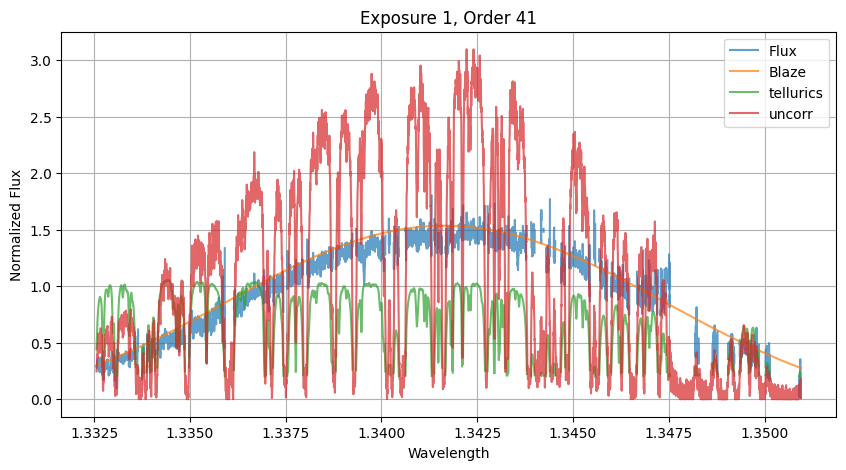

In [43]:
# Select one exposure and one order (e.g., exposure 0 and order 0)
exposure_index = 1
order_index = 41

# Extract the data for the selected exposure and order
selected_wave = wave[exposure_index, order_index]
selected_flux = flux[exposure_index, order_index]
selected_blaze = blaze[exposure_index, order_index]
selected_telluric= tellu[exposure_index, order_index]
selected_uncorr= uncorr[exposure_index, order_index]


# Plot the flux and blaze
plt.figure(figsize=(10, 5))
plt.plot(selected_wave, selected_flux/np.nanmean(selected_flux), label='Flux', alpha=0.7)
plt.plot(selected_wave, selected_blaze/np.nanmean(selected_blaze), label='Blaze', alpha=0.7)
plt.plot(selected_wave, selected_telluric, label='tellurics', alpha=0.7)
plt.plot(selected_wave, selected_uncorr/np.nanmean(selected_uncorr), label='uncorr', alpha=0.7)

#dont normalize telluric spectra

plt.xlabel('Wavelength')
plt.ylabel('Normalized Flux')
plt.title(f'Exposure {exposure_index}, Order {order_index}')
plt.legend()
plt.grid()
plt.show()

In [ ]:
"""
param_all: Reduction parameters
telluric fraction to mask (usually varied between 0.2 and 0.5), 
limits for the wings (fixed at 0.97), 
width of the smoothing kernel for the low pass filter (fixed at 51), 
useless param, 
width of the gaussian kernel for low pass filter (fixed at 5),
nPC to remove (varied between 1 and 5),
sigma clips params (fixed at 5.0)

"""

visit_name = 'HD189733b' #name for the files
mask_wings = 0.9  # Mask wings of deep tellurics

n_RV_inj=151
corrRV0 = np.linspace(-150, 150, n_RV_inj)

# Limb darkening model parameters
# Must specify coefficients and type of model being used, 
# ex: coeffs: [0.22352194, 0.27873135], ld_model: 'quadratic'
# Coefficients for quadratic can be calculated here: https://astroutils.astronomy.osu.edu/exofast/limbdark.shtml
coeffs = [0.23081159,] #coefficients for limb darkening, format wll depend on ld_model type
ld_model = 'linear' #limdarkening model to be used


cbp=True  # Correct bad pixels
kind_trans='emission'#kind of observation

RVsys = [0] #systemic velocity of the system (check gaia)

#########
#these parameters do not need to be changed
iout_all = ['all'] 
polynome = [False] 
do_tr=[1]
transit_tags = [None]
kwargs_gen_tr = {
'coeffs' : coeffs,
'ld_model' : ld_model,
'do_tr' : do_tr,
'kind_trans' : kind_trans,
'polynome' : polynome,
'cbp': cbp
}

kwargs_build_ts = {
'clip_ratio' : 6,
'clip_ts' : 6,
'unberv_it' : True,
}

###############


for n_pc in range(2,3):
    params_all=[[0.20, mask_wings, 51, 41, 5, n_pc, 5.0, 5.0, 5.0, 5.0]]
    list_tr = pl_obs.generate_all_transits(obs, transit_tags, RVsys, params_all, iout_all,
                                           **kwargs_gen_tr, **kwargs_build_ts)

    # Save sequence
    out_filename = f'sequence_{n_pc}-pc_mask_wings{mask_wings*100:n}'
    pl_obs.save_single_sequences(out_filename, list_tr['1'], path=out_dir, filename_end=visit_name)
    
    # Save sequence with only the info needed for a retrieval (to compute log likelihood).
    out_filename = f'retrieval_input_{n_pc}-pc_mask_wings{mask_wings*100:n}'
    pl_obs.save_sequences(out_filename, list_tr, do_tr, path=out_dir)

# Thats it! now lets see what we did

This can now be loaded in another notebook as well. Here we are analyzing the output of our reductions files

In [49]:
#this will plot the summary of mean SNR and airmass for the night
#in the plot red=out of transit, blue= in transit and green=ingress/egress
pl_obs.load_single_sequences?

Signature:
pl_obs.load_single_sequences(
    filename,
    name,
    path='',
    load_all=False,
    filename_end='',
    plot=True,
    **kwargs,
)
Docstring: <no docstring>
File:      /usr/local/lib/python3.10/site-packages/starships-1.0.0-py3.10.egg/starships/planet_obs.py
Type:      function

Transmission


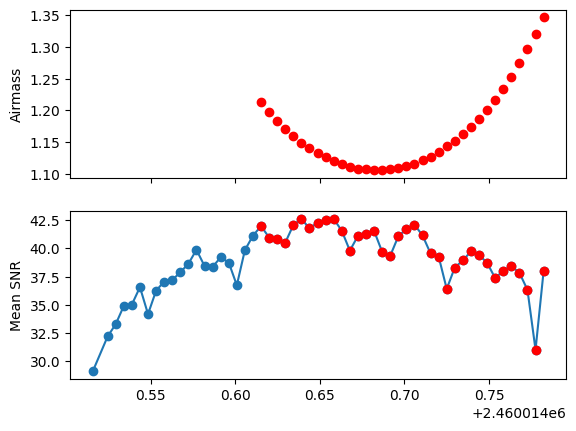

In [44]:
pl_obs.load_single_sequences('filename',
                             name=, planet=, path=out_dir)


In [50]:

pf.plot_steps?

Signature:
pf.plot_steps(
    tr,
    iord,
    xlim=None,
    masking_limit=None,
    id_spec=0,
    fig_name='',
    cmap=None,
    bad_color='red',
    path_fig=None,
)
Docstring: <no docstring>
File:      /usr/local/lib/python3.10/site-packages/starships-1.0.0-py3.10.egg/starships/plotting_fcts.py
Type:      function

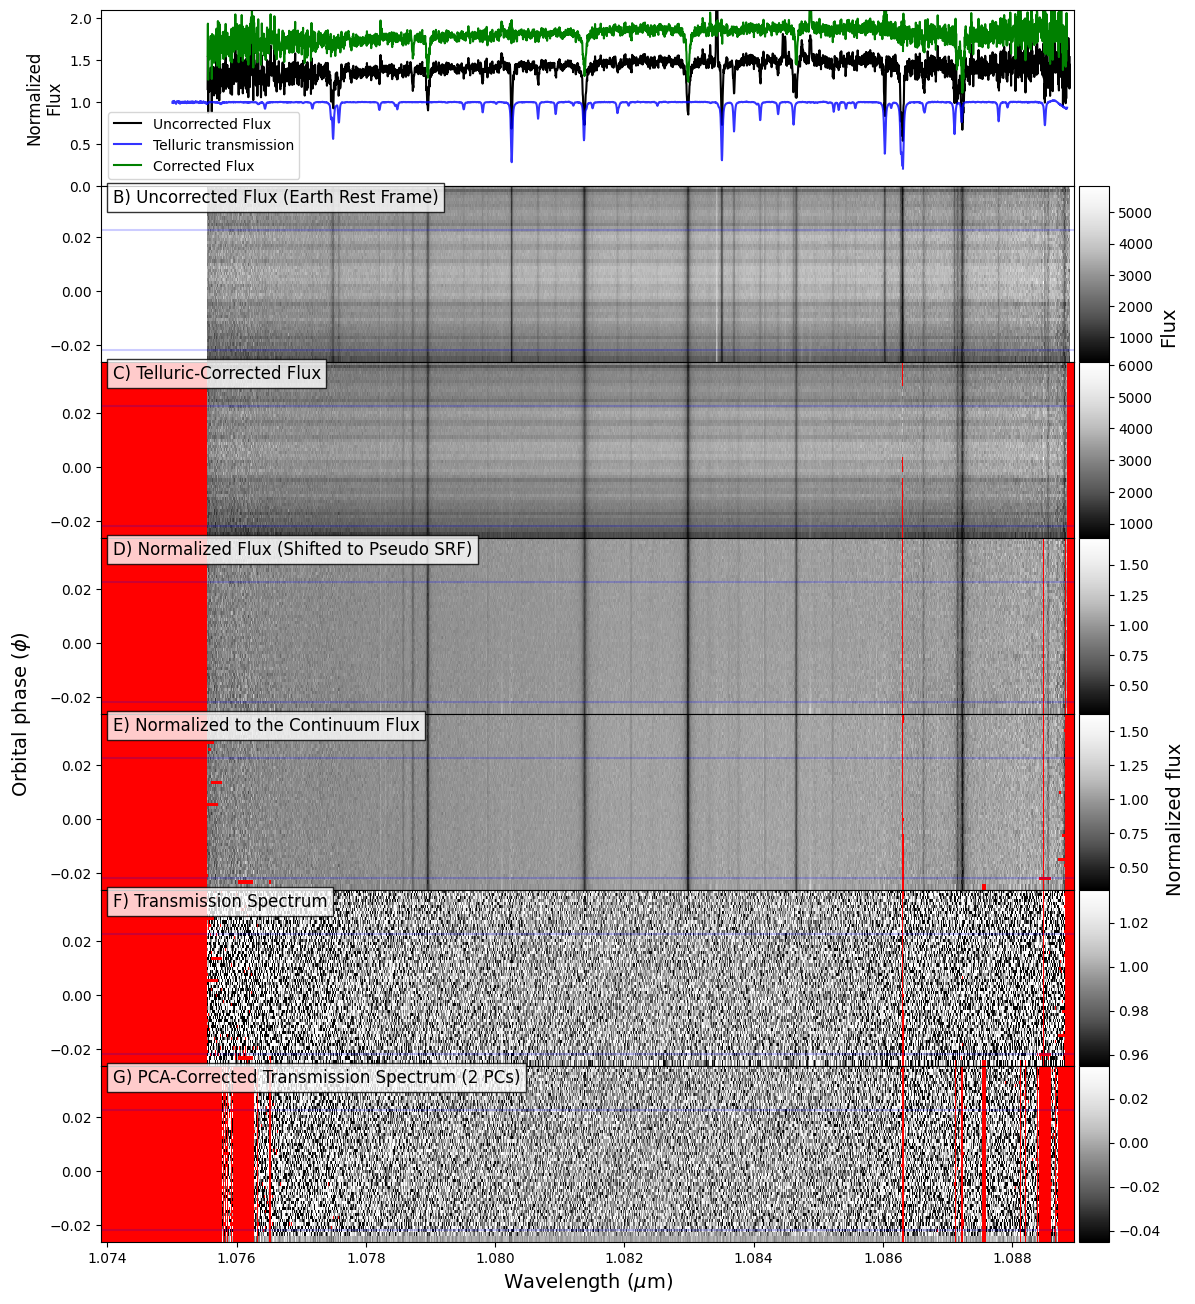

In [45]:
pf.plot_steps(list_tr['1'], order)
